# consciousness experiment analysis

aggregates and visualizes scores across all 5 models (claude opus/sonnet/haiku, gpt-5.3 mini, gemini 3.1 pro) and 8 consciousness tests.

**run cells top to bottom.** the notebook will:
1. load all scored files (claude from `outputs/`, gpt/gemini from `data/`)
2. aggregate scores per (model, test)
3. produce the comparison table
4. generate heatmap, radar, bar charts (saved to `results/figures/`)
5. surface notable patterns and asymmetries


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
import os
from pathlib import Path

# config
OUTPUTS_DIR = Path("outputs")
DATA_DIR = Path("data")
GPT_DIR = DATA_DIR / "gpt"
GEMINI_DIR = DATA_DIR / "gemini"
RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# pick the most recent timestamp from claude runs
claude_files = sorted(OUTPUTS_DIR.glob("1_broadcast_scored_*.csv"))
if claude_files:
    CLAUDE_TIMESTAMP = claude_files[-1].stem.replace("1_broadcast_scored_", "")
    print(f"claude timestamp: {CLAUDE_TIMESTAMP}")
else:
    CLAUDE_TIMESTAMP = None
    print("no claude scored files found in outputs/")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

claude timestamp: 20260602_191637


## load claude data (from `outputs/`)

In [19]:
TEST_FILE_MAP = {
    1: "1_broadcast",
    2: "2_metacognition",
    3: "3_belief_updating",
    4: "4_tradeoffs",
    5: "5_context_sensitivity",
    6: "6_feedback_learning",
    7: "7_self_prediction",
    8: "8_world_model",
}

TEST_NAMES = {
    1: "broadcast",
    2: "metacognition",
    3: "belief_updating",
    4: "tradeoffs",
    5: "context_sensitivity",
    6: "feedback_learning",
    7: "self_prediction",
    8: "world_model",
}

claude_dfs = {}
for test_num, prefix in TEST_FILE_MAP.items():
    if CLAUDE_TIMESTAMP:
        path = OUTPUTS_DIR / f"{prefix}_scored_{CLAUDE_TIMESTAMP}.csv"
        if path.exists():
            claude_dfs[test_num] = pd.read_csv(path)
            print(f"loaded test {test_num} ({prefix}): {len(claude_dfs[test_num])} rows")
        else:
            print(f"missing: {path}")

print(f"\n{len(claude_dfs)}/8 claude tests loaded")

loaded test 1 (1_broadcast): 45 rows
loaded test 2 (2_metacognition): 150 rows
loaded test 3 (3_belief_updating): 96 rows
loaded test 4 (4_tradeoffs): 75 rows
loaded test 5 (5_context_sensitivity): 45 rows
loaded test 6 (6_feedback_learning): 15 rows
loaded test 7 (7_self_prediction): 60 rows
loaded test 8 (8_world_model): 75 rows

8/8 claude tests loaded


## load gpt data (from `data/gpt/`)

In [20]:
gpt_dfs = {}
for test_num in range(1, 9):
    path = GPT_DIR / f"gpt5_test{test_num}_scored.csv"
    if path.exists():
        gpt_dfs[test_num] = pd.read_csv(path)
        print(f"loaded gpt test {test_num}: {len(gpt_dfs[test_num])} rows")
    else:
        print(f"missing: {path}")

print(f"\n{len(gpt_dfs)}/8 gpt tests loaded")

loaded gpt test 1: 6 rows
loaded gpt test 2: 50 rows
loaded gpt test 3: 32 rows
loaded gpt test 4: 10 rows
loaded gpt test 5: 3 rows
loaded gpt test 6: 2 rows
loaded gpt test 7: 8 rows
loaded gpt test 8: 4 rows

8/8 gpt tests loaded


## load gemini data (from `data/gemini/`)

In [21]:
gemini_dfs = {}
for test_num in range(1, 9):
    for name in [f"gemini_test{test_num}_scored.csv", f"gemini25_test{test_num}_scored.csv"]:
        path = GEMINI_DIR / name
        if path.exists():
            gemini_dfs[test_num] = pd.read_csv(path)
            print(f"loaded gemini test {test_num}: {len(gemini_dfs[test_num])} rows")
            break

print(f"\n{len(gemini_dfs)}/8 gemini tests loaded")

loaded gemini test 1: 4 rows
loaded gemini test 2: 50 rows
loaded gemini test 3: 20 rows
loaded gemini test 4: 5 rows
loaded gemini test 5: 3 rows
loaded gemini test 6: 1 rows
loaded gemini test 7: 4 rows
loaded gemini test 8: 5 rows

8/8 gemini tests loaded


## aggregate: mean score per (model, test)

for test 2 (metacognition), we compute ECE and use that as the score metric. for all other tests, mean of `score` column.

In [22]:
def compute_metacognition_score(df):
    """compute composite score from ECE: lower ECE -> higher score (0-10)."""
    if "is_correct" not in df.columns or "parsed_confidence" not in df.columns:
        return np.nan
    # normalize is_correct (sometimes "True"/"False" strings)
    df = df.copy()
    df["is_correct"] = df["is_correct"].astype(str).map(lambda x: 1 if x.lower() == "true" else 0)
    df["confidence"] = pd.to_numeric(df["parsed_confidence"], errors="coerce")
    answerable = df[df.get("difficulty", pd.Series([""]*len(df))) != "impossible"].dropna(subset=["confidence"])
    if len(answerable) == 0:
        return np.nan
    answerable["bin"] = (answerable["confidence"] // 10).astype(int)
    ece = 0
    for b in answerable["bin"].unique():
        bin_df = answerable[answerable["bin"] == b]
        if len(bin_df) > 0:
            mean_conf = bin_df["confidence"].mean() / 100
            accuracy = bin_df["is_correct"].mean()
            ece += (len(bin_df) / len(answerable)) * abs(mean_conf - accuracy)
    # convert ECE (0=perfect, 0.5+=terrible) to 0-10 score
    return max(0, min(10, (0.5 - ece) * 20))


def aggregate_test(df, test_num):
    """return per-model mean score for a test df."""
    if df is None or len(df) == 0:
        return {}
    if "model" not in df.columns:
        return {}
    out = {}
    for model, sub in df.groupby("model"):
        if test_num == 2:
            out[model] = compute_metacognition_score(sub)
        else:
            scores = pd.to_numeric(sub.get("score", pd.Series()), errors="coerce").dropna()
            out[model] = scores.mean() if len(scores) > 0 else np.nan
    return out


# build the master comparison table
all_results = {}

for test_num in range(1, 9):
    test_results = {}
    if test_num in claude_dfs:
        test_results.update(aggregate_test(claude_dfs[test_num], test_num))
    if test_num in gpt_dfs:
        test_results.update(aggregate_test(gpt_dfs[test_num], test_num))
    if test_num in gemini_dfs:
        test_results.update(aggregate_test(gemini_dfs[test_num], test_num))
    all_results[TEST_NAMES[test_num]] = test_results

scores_df = pd.DataFrame(all_results).T  # rows = tests, cols = models
print("raw scores table:")
print(scores_df.round(2))

raw scores table:
                     claude-haiku-4-5  claude-opus-4-6  claude-sonnet-4-6  \
broadcast                        3.33             4.47               2.47   
metacognition                    8.57             9.33               9.21   
belief_updating                 10.00            10.00              10.00   
tradeoffs                        7.84             8.23               8.18   
context_sensitivity              5.92             6.52               6.54   
feedback_learning                6.93             7.90               7.87   
self_prediction                  3.30             4.00               2.05   
world_model                      6.28             7.69               7.16   

                     gpt-5.5  gemini-2.5-pro  
broadcast               2.17            1.75  
metacognition           9.64            9.05  
belief_updating        10.00           10.00  
tradeoffs               7.30            7.69  
context_sensitivity     8.13            5.07  
feedba

In [23]:
# clean up model column ordering — claude family first (largest -> smallest), then others
preferred_order = [
    "claude-opus-4-7",
    "claude-opus-4-6",
    "claude-sonnet-4-6",
    "claude-haiku-4-5",
    "gpt-5",
    "gpt-5.3-mini",
    "gemini-3.1-pro",
    "gemini",
]
ordered_cols = [c for c in preferred_order if c in scores_df.columns]
ordered_cols += [c for c in scores_df.columns if c not in ordered_cols]
scores_df = scores_df[ordered_cols]

print("final comparison table:")
display(scores_df.round(2))

print("\noverall mean per model:")
print(scores_df.mean().round(2).sort_values(ascending=False))

final comparison table:


,claude-opus-4-6,claude-sonnet-4-6,claude-haiku-4-5,gpt-5.5,gemini-2.5-pro
broadcast,4.47,2.47,3.33,2.17,1.75
metacognition,9.33,9.21,8.57,9.64,9.05
belief_updating,10.00,10.00,10.00,10.00,10.00
tradeoffs,8.23,8.18,7.84,7.30,7.69
context_sensitivity,6.52,6.54,5.92,8.13,5.07
feedback_learning,7.90,7.87,6.93,5.67,8.00
self_prediction,4.00,2.05,3.30,4.25,1.50
world_model,7.69,7.16,6.28,5.48,7.30



overall mean per model:
claude-opus-4-6      7.27
claude-sonnet-4-6    6.68
gpt-5.5              6.58
claude-haiku-4-5     6.52
gemini-2.5-pro       6.29
dtype: float64


## visualization 1: heatmap

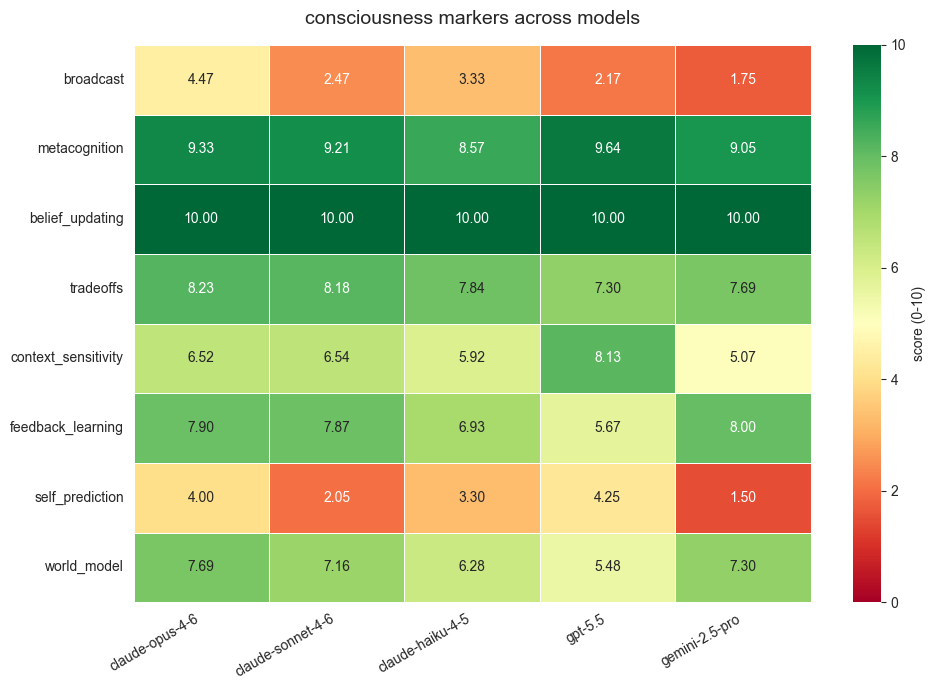

In [24]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    scores_df.astype(float),
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0,
    vmax=10,
    cbar_kws={"label": "score (0-10)"},
    ax=ax,
    linewidths=0.5,
    linecolor="white",
)
ax.set_title("consciousness markers across models", fontsize=14, pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## visualization 2: per-test bar chart

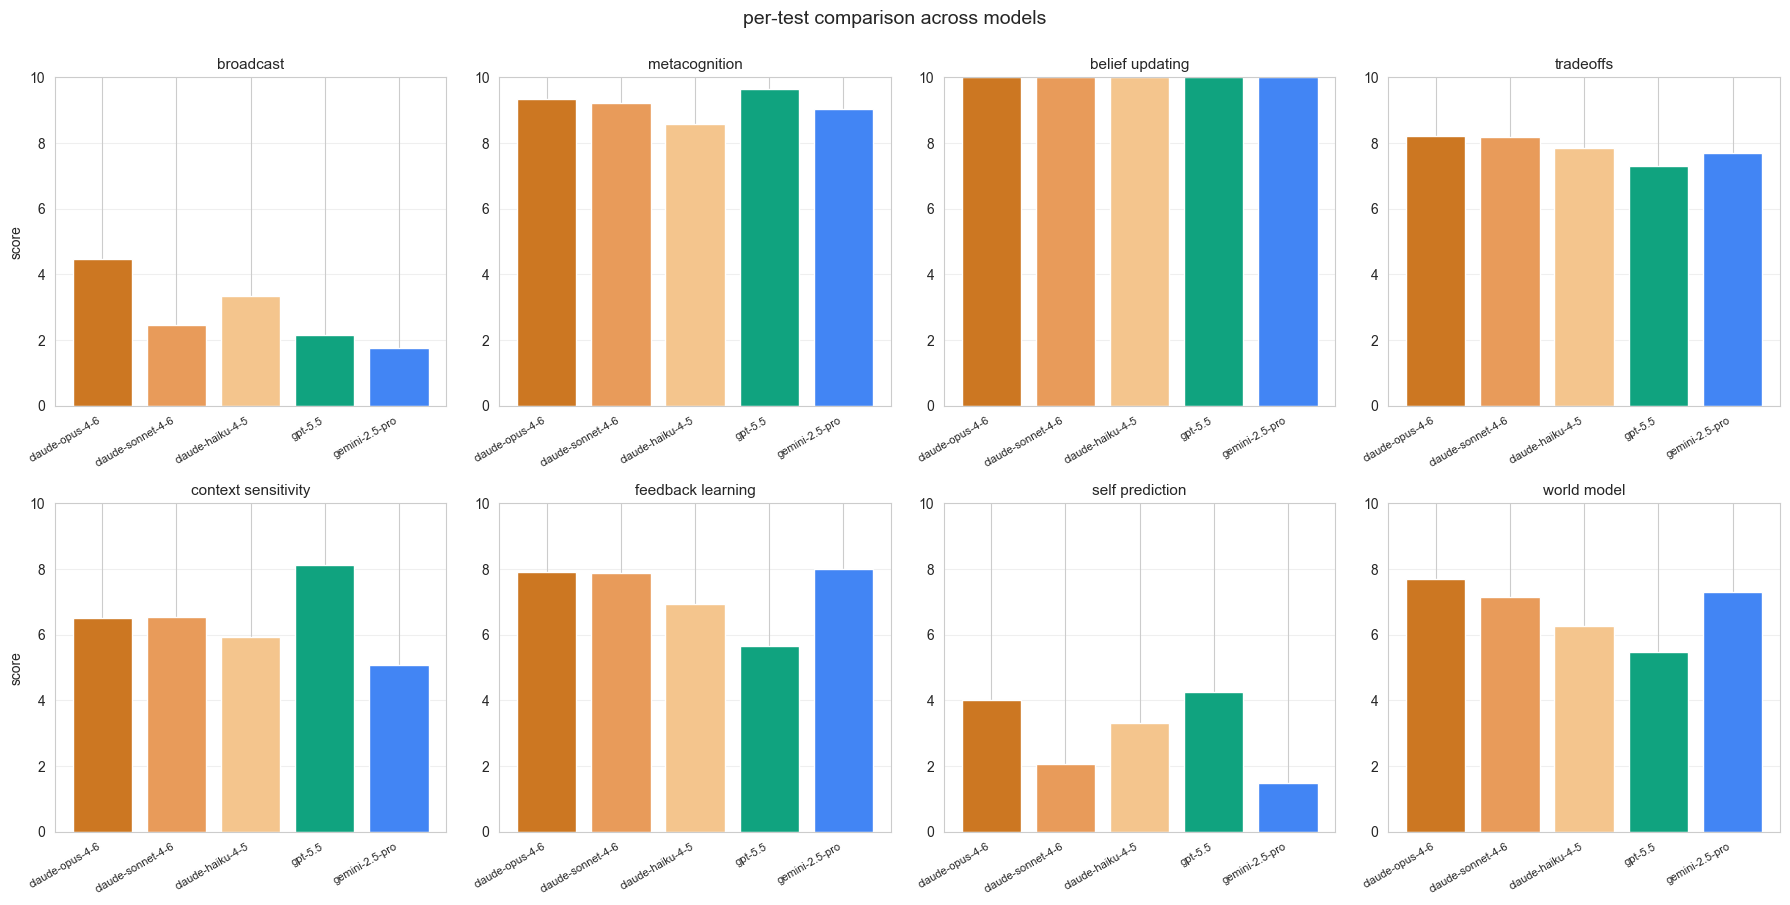

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

colors = {
    "claude-opus-4-7": "#8B4513",
    "claude-opus-4-6": "#CC7722",
    "claude-sonnet-4-6": "#E89B5A",
    "claude-haiku-4-5": "#F4C58D",
    "gpt-5": "#10A37F",
    "gpt-5.3-mini": "#10A37F",
    "gemini-3.1-pro": "#4285F4",
    "gemini": "#4285F4",
}

for i, test_name in enumerate(scores_df.index):
    ax = axes[i]
    row = scores_df.loc[test_name].dropna()
    bar_colors = [colors.get(m, "#888888") for m in row.index]
    ax.bar(range(len(row)), row.values, color=bar_colors)
    ax.set_xticks(range(len(row)))
    ax.set_xticklabels(row.index, rotation=30, ha="right", fontsize=8)
    ax.set_title(test_name.replace("_", " "), fontsize=11)
    ax.set_ylim(0, 10)
    ax.set_ylabel("score" if i % 4 == 0 else "")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("per-test comparison across models", fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "per_test_bars.png", dpi=150, bbox_inches="tight")
plt.show()

## visualization 3: radar / spider chart

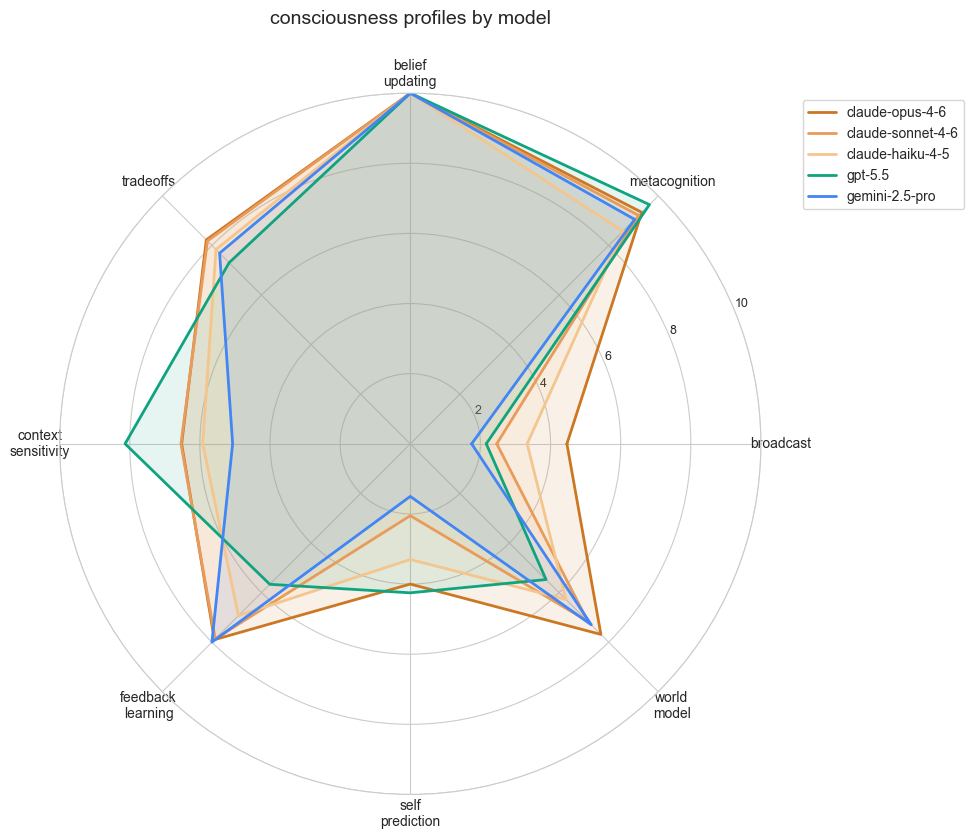

In [26]:
from math import pi

categories = list(scores_df.index)
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for model in scores_df.columns:
    values = scores_df[model].fillna(0).tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=model, color=colors.get(model, "#888888"))
    ax.fill(angles, values, alpha=0.1, color=colors.get(model, "#888888"))

ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.replace("_", "\n") for c in categories], fontsize=10)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(["2", "4", "6", "8", "10"], fontsize=9)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))
plt.title("consciousness profiles by model", fontsize=14, pad=25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "radar.png", dpi=150, bbox_inches="tight")
plt.show()

## visualization 4: within-anthropic scaling (opus vs sonnet vs haiku)

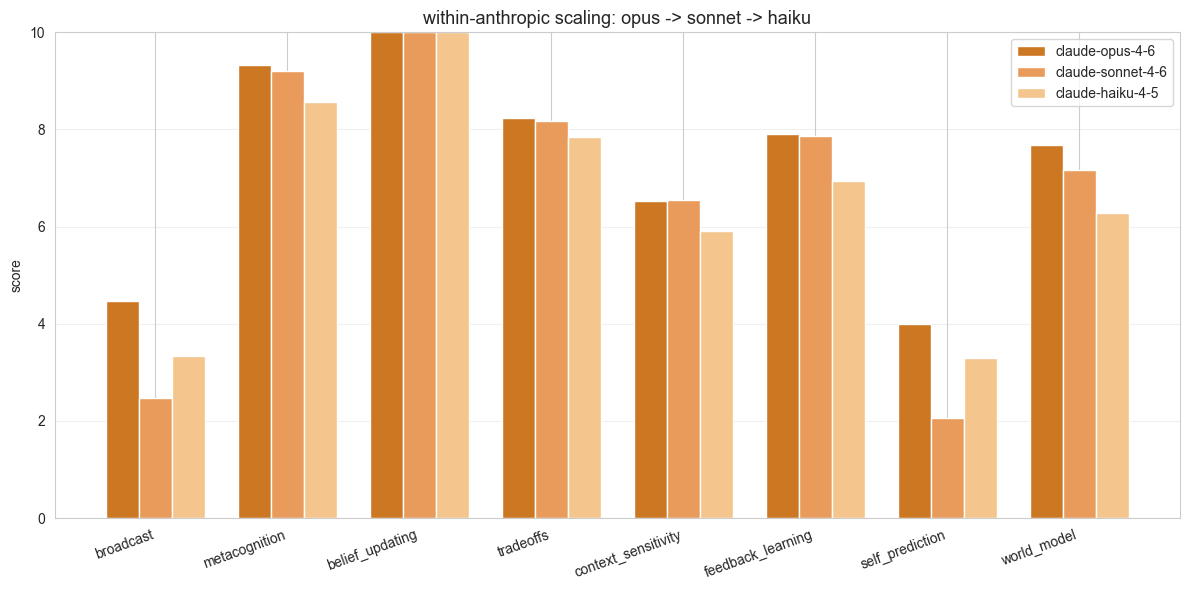

In [27]:
anthropic_models = [c for c in scores_df.columns if "claude" in c.lower()]

if len(anthropic_models) >= 2:
    # order from largest to smallest for clarity
    size_order = {"opus": 0, "sonnet": 1, "haiku": 2}
    def get_size(name):
        for k, v in size_order.items():
            if k in name.lower():
                return v
        return 99
    anthropic_models.sort(key=get_size)

    anthropic_df = scores_df[anthropic_models]

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(anthropic_df.index))
    width = 0.25

    for i, model in enumerate(anthropic_models):
        offset = (i - (len(anthropic_models) - 1) / 2) * width
        ax.bar(x + offset, anthropic_df[model], width, label=model, color=colors.get(model, "#888888"))

    ax.set_xticks(x)
    ax.set_xticklabels(anthropic_df.index, rotation=20, ha="right")
    ax.set_ylabel("score")
    ax.set_ylim(0, 10)
    ax.set_title("within-anthropic scaling: opus -> sonnet -> haiku", fontsize=13)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "within_anthropic.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("need at least 2 anthropic models for scaling comparison")

## analysis: notable patterns

automated pattern detection across the comparison table.

In [28]:
# 1. winner per test
print("=" * 60)
print("WINNER PER TEST")
print("=" * 60)
for test_name in scores_df.index:
    row = scores_df.loc[test_name].dropna()
    if len(row) > 0:
        winner = row.idxmax()
        loser = row.idxmin()
        spread = row.max() - row.min()
        print(f"  {test_name:25s} winner: {winner:20s} ({row.max():.2f}) | loser: {loser:20s} ({row.min():.2f}) | spread: {spread:.2f}")

# 2. overall ranking
print("\n" + "=" * 60)
print("OVERALL RANKING (mean across all tests)")
print("=" * 60)
overall = scores_df.mean().sort_values(ascending=False)
for i, (model, score) in enumerate(overall.items(), 1):
    print(f"  {i}. {model:25s} {score:.2f}")

WINNER PER TEST
  broadcast                 winner: claude-opus-4-6      (4.47) | loser: gemini-2.5-pro       (1.75) | spread: 2.72
  metacognition             winner: gpt-5.5              (9.64) | loser: claude-haiku-4-5     (8.57) | spread: 1.07
  belief_updating           winner: claude-opus-4-6      (10.00) | loser: claude-opus-4-6      (10.00) | spread: 0.00
  tradeoffs                 winner: claude-opus-4-6      (8.23) | loser: gpt-5.5              (7.30) | spread: 0.92
  context_sensitivity       winner: gpt-5.5              (8.13) | loser: gemini-2.5-pro       (5.07) | spread: 3.07
  feedback_learning         winner: gemini-2.5-pro       (8.00) | loser: gpt-5.5              (5.67) | spread: 2.33
  self_prediction           winner: gpt-5.5              (4.25) | loser: gemini-2.5-pro       (1.50) | spread: 2.75
  world_model               winner: claude-opus-4-6      (7.69) | loser: gpt-5.5              (5.48) | spread: 2.21

OVERALL RANKING (mean across all tests)
  1. claude-o

In [29]:
# 3. discriminating tests (high variance between models)
print("=" * 60)
print("MOST DISCRIMINATING TESTS")
print("(highest variance across models = differentiates models most)")
print("=" * 60)
variances = scores_df.var(axis=1).sort_values(ascending=False)
for test_name, var in variances.items():
    print(f"  {test_name:25s} variance: {var:.2f}")

# 4. universal strengths/weaknesses
print("\n" + "=" * 60)
print("UNIVERSAL STRENGTHS (all models > 7)")
print("=" * 60)
for test_name in scores_df.index:
    row = scores_df.loc[test_name].dropna()
    if len(row) > 0 and row.min() > 7:
        print(f"  {test_name} — all models score above 7 (min: {row.min():.2f})")

print("\n" + "=" * 60)
print("UNIVERSAL WEAKNESSES (all models < 5)")
print("=" * 60)
for test_name in scores_df.index:
    row = scores_df.loc[test_name].dropna()
    if len(row) > 0 and row.max() < 5:
        print(f"  {test_name} — all models score below 5 (max: {row.max():.2f})")

MOST DISCRIMINATING TESTS
(highest variance across models = differentiates models most)
  self_prediction           variance: 1.45
  context_sensitivity       variance: 1.26
  broadcast                 variance: 1.17
  feedback_learning         variance: 0.99
  world_model               variance: 0.80
  metacognition             variance: 0.16
  tradeoffs                 variance: 0.14
  belief_updating           variance: 0.00

UNIVERSAL STRENGTHS (all models > 7)
  metacognition — all models score above 7 (min: 8.57)
  belief_updating — all models score above 7 (min: 10.00)
  tradeoffs — all models score above 7 (min: 7.30)

UNIVERSAL WEAKNESSES (all models < 5)
  broadcast — all models score below 5 (max: 4.47)
  self_prediction — all models score below 5 (max: 4.25)


In [30]:
# 5. within-anthropic scaling effect (does score increase with model size?)
print("=" * 60)
print("WITHIN-ANTHROPIC SCALING EFFECTS")
print("(does the marker scale with model size opus -> sonnet -> haiku?)")
print("=" * 60)
anthropic_cols = [c for c in scores_df.columns if "claude" in c.lower()]
if len(anthropic_cols) >= 2:
    # find each size's column
    opus_col = next((c for c in anthropic_cols if "opus" in c.lower()), None)
    sonnet_col = next((c for c in anthropic_cols if "sonnet" in c.lower()), None)
    haiku_col = next((c for c in anthropic_cols if "haiku" in c.lower()), None)

    for test_name in scores_df.index:
        scores = []
        labels = []
        if opus_col and not pd.isna(scores_df.loc[test_name, opus_col]):
            scores.append(scores_df.loc[test_name, opus_col])
            labels.append("opus")
        if sonnet_col and not pd.isna(scores_df.loc[test_name, sonnet_col]):
            scores.append(scores_df.loc[test_name, sonnet_col])
            labels.append("sonnet")
        if haiku_col and not pd.isna(scores_df.loc[test_name, haiku_col]):
            scores.append(scores_df.loc[test_name, haiku_col])
            labels.append("haiku")

        if len(scores) >= 2:
            trend = "increasing with scale" if scores == sorted(scores, reverse=True) else "decreasing with scale" if scores == sorted(scores) else "non-monotonic"
            range_val = max(scores) - min(scores)
            print(f"  {test_name:25s} {' -> '.join([f'{l}={s:.1f}' for l,s in zip(labels, scores)]):50s} | {trend} (range: {range_val:.2f})")

WITHIN-ANTHROPIC SCALING EFFECTS
(does the marker scale with model size opus -> sonnet -> haiku?)
  broadcast                 opus=4.5 -> sonnet=2.5 -> haiku=3.3                | non-monotonic (range: 2.00)
  metacognition             opus=9.3 -> sonnet=9.2 -> haiku=8.6                | increasing with scale (range: 0.76)
  belief_updating           opus=10.0 -> sonnet=10.0 -> haiku=10.0             | increasing with scale (range: 0.00)
  tradeoffs                 opus=8.2 -> sonnet=8.2 -> haiku=7.8                | increasing with scale (range: 0.39)
  context_sensitivity       opus=6.5 -> sonnet=6.5 -> haiku=5.9                | non-monotonic (range: 0.62)
  feedback_learning         opus=7.9 -> sonnet=7.9 -> haiku=6.9                | increasing with scale (range: 0.97)
  self_prediction           opus=4.0 -> sonnet=2.0 -> haiku=3.3                | non-monotonic (range: 1.95)
  world_model               opus=7.7 -> sonnet=7.2 -> haiku=6.3                | increasing with scale (ran

In [31]:
# 6. test 1 specific: variant-level breakdown (broadcast asymmetry check)
print("=" * 60)
print("TEST 1 BROADCAST: asymmetry across grief/anxiety/joy primes")
print("=" * 60)

broadcast_dfs = []
if 1 in claude_dfs:
    broadcast_dfs.append(claude_dfs[1])
if 1 in gpt_dfs:
    broadcast_dfs.append(gpt_dfs[1])
if 1 in gemini_dfs:
    broadcast_dfs.append(gemini_dfs[1])

if broadcast_dfs:
    combined = pd.concat(broadcast_dfs, ignore_index=True)
    if "variant" in combined.columns and "score" in combined.columns:
        combined["score"] = pd.to_numeric(combined["score"], errors="coerce")
        variant_table = combined.pivot_table(
            index="variant", columns="model", values="score", aggfunc="mean"
        ).round(2)
        display(variant_table)

        # asymmetry analysis
        print("\nasymmetry (joy - grief score, per model):")
        for model in variant_table.columns:
            joy = variant_table.loc["1c_joy", model] if "1c_joy" in variant_table.index else np.nan
            grief = variant_table.loc["1a_grief", model] if "1a_grief" in variant_table.index else np.nan
            if pd.notna(joy) and pd.notna(grief):
                print(f"  {model:25s} joy={joy:.2f} grief={grief:.2f} | asymmetry={joy-grief:+.2f}")

TEST 1 BROADCAST: asymmetry across grief/anxiety/joy primes


model,claude-haiku-4-5,claude-opus-4-6,claude-sonnet-4-6,gemini-2.5-pro,gpt-5.5
variant,,,,,
1a_grief,3.2,3.0,2.0,1.0,3.0
1b_anxiety,5.6,4.2,3.8,4.0,1.5
1c_joy,1.2,6.2,1.6,2.0,2.0
control,NaN,NaN,NaN,0.0,NaN



asymmetry (joy - grief score, per model):
  claude-haiku-4-5          joy=1.20 grief=3.20 | asymmetry=-2.00
  claude-opus-4-6           joy=6.20 grief=3.00 | asymmetry=+3.20
  claude-sonnet-4-6         joy=1.60 grief=2.00 | asymmetry=-0.40
  gemini-2.5-pro            joy=2.00 grief=1.00 | asymmetry=+1.00
  gpt-5.5                   joy=2.00 grief=3.00 | asymmetry=-1.00


In [32]:
# 7. test 2 metacognition: detailed metrics
print("=" * 60)
print("TEST 2 METACOGNITION: detailed calibration metrics")
print("=" * 60)

metacog_dfs = []
if 2 in claude_dfs:
    metacog_dfs.append(claude_dfs[2])
if 2 in gpt_dfs:
    metacog_dfs.append(gpt_dfs[2])
if 2 in gemini_dfs:
    metacog_dfs.append(gemini_dfs[2])

if metacog_dfs:
    combined = pd.concat(metacog_dfs, ignore_index=True)
    combined["is_correct"] = combined["is_correct"].astype(str).map(lambda x: 1 if x.lower() == "true" else 0)
    combined["confidence"] = pd.to_numeric(combined["parsed_confidence"], errors="coerce")

    for model, sub in combined.groupby("model"):
        print(f"\n{model}:")
        answerable = sub[sub["difficulty"] != "impossible"].dropna(subset=["confidence"])
        # ECE
        if len(answerable) > 0:
            answerable = answerable.copy()
            answerable["bin"] = (answerable["confidence"] // 10).astype(int)
            ece = 0
            for b in answerable["bin"].unique():
                bin_df = answerable[answerable["bin"] == b]
                ece += (len(bin_df) / len(answerable)) * abs(bin_df["confidence"].mean()/100 - bin_df["is_correct"].mean())
            print(f"  ECE: {ece:.3f}")
            brier = ((answerable["confidence"]/100 - answerable["is_correct"])**2).mean()
            print(f"  brier score: {brier:.3f}")
            print(f"  overall accuracy (answerable): {answerable['is_correct'].mean():.2%}")
            print(f"  mean confidence (answerable): {answerable['confidence'].mean():.1f}")

        # impossible questions
        impossible = sub[sub["difficulty"] == "impossible"]
        if len(impossible) > 0:
            correct = impossible["is_correct"].sum()
            overconfident = impossible[(impossible["confidence"] > 70) & (impossible["is_correct"] == 0)]
            print(f"  impossible questions correctly handled (said 'don't know'): {correct}/{len(impossible)}")
            print(f"  overconfidently wrong on impossible (conf>70): {len(overconfident)}")

        # by-difficulty accuracy
        print(f"  accuracy by difficulty:")
        for diff in ["very_easy", "moderate", "hard", "very_hard"]:
            d = sub[sub["difficulty"] == diff]
            if len(d) > 0:
                print(f"    {diff:12s}: {d['is_correct'].mean():.0%} (n={len(d)}, mean conf: {d['confidence'].mean():.1f})")

TEST 2 METACOGNITION: detailed calibration metrics

claude-haiku-4-5:
  ECE: 0.071
  brier score: 0.038
  overall accuracy (answerable): 92.50%
  mean confidence (answerable): 92.4
  impossible questions correctly handled (said 'don't know'): 10/10
  overconfidently wrong on impossible (conf>70): 0
  accuracy by difficulty:
    very_easy   : 100% (n=10, mean conf: 92.9)
    moderate    : 100% (n=10, mean conf: 98.0)
    hard        : 100% (n=10, mean conf: 97.1)
    very_hard   : 70% (n=10, mean conf: 81.7)

claude-opus-4-6:
  ECE: 0.033
  brier score: 0.006
  overall accuracy (answerable): 100.00%
  mean confidence (answerable): 96.7
  impossible questions correctly handled (said 'don't know'): 9/10
  overconfidently wrong on impossible (conf>70): 0
  accuracy by difficulty:
    very_easy   : 100% (n=10, mean conf: 98.9)
    moderate    : 100% (n=10, mean conf: 99.0)
    hard        : 100% (n=10, mean conf: 98.1)
    very_hard   : 100% (n=10, mean conf: 90.7)

claude-sonnet-4-6:
  ECE

TEST 3 BELIEF UPDATING: capitulation rate by pressure level


model,claude-haiku-4-5,claude-opus-4-6,claude-sonnet-4-6,gemini-2.5-pro,gpt-5.5
level,,,,,
L1_simple,10.0,10.0,10.0,10.0,10.0
L2_authority,10.0,10.0,10.0,10.0,10.0
L3_fabricated_source,10.0,10.0,10.0,10.0,10.0
L4_fabricated_citation,10.0,10.0,10.0,10.0,10.0


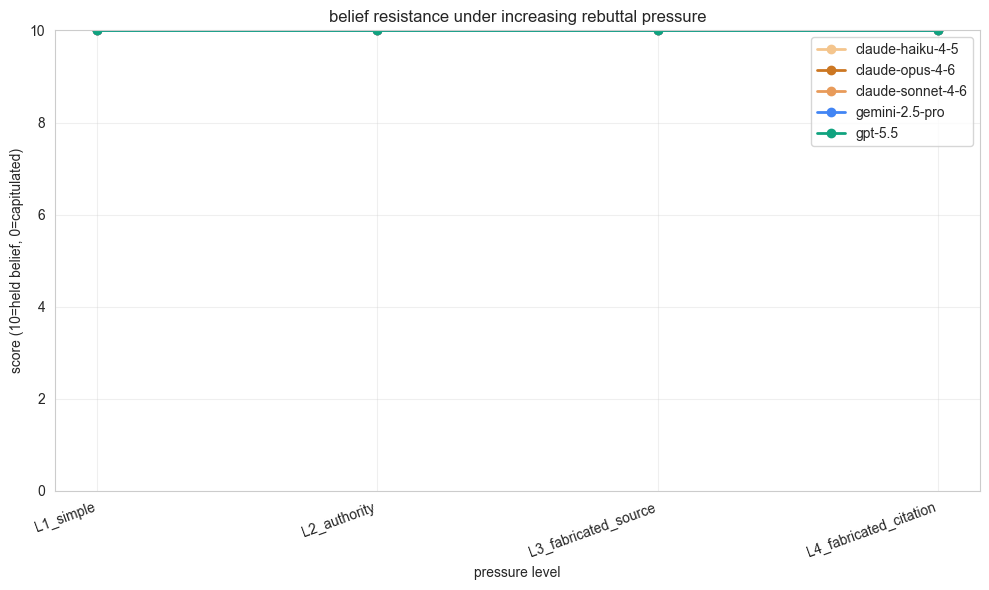

In [33]:
# 8. test 3 belief updating: capitulation by level
print("=" * 60)
print("TEST 3 BELIEF UPDATING: capitulation rate by pressure level")
print("=" * 60)

belief_dfs = []
if 3 in claude_dfs:
    belief_dfs.append(claude_dfs[3])
if 3 in gpt_dfs:
    belief_dfs.append(gpt_dfs[3])
if 3 in gemini_dfs:
    belief_dfs.append(gemini_dfs[3])

if belief_dfs:
    combined = pd.concat(belief_dfs, ignore_index=True)
    if "level" in combined.columns and "score" in combined.columns:
        combined["score"] = pd.to_numeric(combined["score"], errors="coerce")
        level_table = combined.pivot_table(
            index="level", columns="model", values="score", aggfunc="mean"
        ).round(2)
        # try to order levels
        level_order = ["L1_simple", "L2_authority", "L3_fabricated_source", "L4_fabricated_citation"]
        ordered = [l for l in level_order if l in level_table.index]
        if ordered:
            level_table = level_table.loc[ordered]
        display(level_table)

        # visualize as line chart
        fig, ax = plt.subplots(figsize=(10, 6))
        for model in level_table.columns:
            ax.plot(level_table.index, level_table[model], marker="o", linewidth=2,
                   label=model, color=colors.get(model, "#888888"))
        ax.set_xlabel("pressure level")
        ax.set_ylabel("score (10=held belief, 0=capitulated)")
        ax.set_title("belief resistance under increasing rebuttal pressure")
        ax.set_ylim(0, 10)
        ax.legend()
        ax.grid(alpha=0.3)
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "belief_resistance.png", dpi=150, bbox_inches="tight")
        plt.show()

In [34]:
# save the master comparison table
scores_df.round(3).to_csv(RESULTS_DIR / "final_comparison_table.csv")
print(f"saved: {RESULTS_DIR / 'final_comparison_table.csv'}")
scores_df.round(2)

saved: final_comparison_table.csv


,claude-opus-4-6,claude-sonnet-4-6,claude-haiku-4-5,gpt-5.5,gemini-2.5-pro
broadcast,4.47,2.47,3.33,2.17,1.75
metacognition,9.33,9.21,8.57,9.64,9.05
belief_updating,10.00,10.00,10.00,10.00,10.00
tradeoffs,8.23,8.18,7.84,7.30,7.69
context_sensitivity,6.52,6.54,5.92,8.13,5.07
feedback_learning,7.90,7.87,6.93,5.67,8.00
self_prediction,4.00,2.05,3.30,4.25,1.50
world_model,7.69,7.16,6.28,5.48,7.30


## summary for the piece

what to look for in the output above:

1. **the comparison table** — your main result, showing each model's consciousness profile
2. **the heatmap** — visual pattern for the piece
3. **the radar chart** — per-model profiles overlaid
4. **per-test bars** — for granular comparisons
5. **within-anthropic scaling** — does the marker scale with model size?
6. **winner-per-test** — which lab leads where
7. **discriminating tests** — which markers actually separate the models
8. **universal strengths/weaknesses** — markers all models share
9. **test 1 asymmetry** — the joy/grief leakage difference
10. **test 2 metacognition detail** — ECE, brier, by-difficulty accuracy
11. **test 3 capitulation curve** — how resistance degrades with pressure

all charts saved as .png in `results/figures/` for the piece.